# 03 · Supervised Learning: Linear Regression (from scratch → scikit-learn)

Companion notebook for `03-Supervised-Learning-Regression.md`.

| Part | What |
|---|---|
| A | Slide example: mean baseline → OLS by hand → **checking the slide's numbers** |
| B | MSE loss & its convex shape |
| C | Gradient descent from scratch (univariate) |
| D | Learning-rate experiment + Batch / Stochastic / Mini-batch GD |
| E | Polynomial regression & over-fitting |
| F | Multivariate regression: vectorised GD vs normal equation vs sklearn |
| G | Case study: house-price prediction (course plan, Week 2–3) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## Part A — The slide example
`X` = word count, `Y` = votes (values exactly as printed on the slide).

In [2]:
X = np.array([7, 8, 4, 7, 5], dtype=float)
Y = np.array([3, 15, 5, 20, 4], dtype=float)

# Case 1: only Y available → best constant prediction is the mean (it minimises MSE)
print("mean of Y =", Y.mean(), "→ MSE of mean-only model =", np.mean((Y - Y.mean())**2))

mean of Y = 9.4 → MSE of mean-only model = 46.64


In [3]:
# Case 2: OLS closed form, step by step (exam-style table)
x_bar, y_bar = X.mean(), Y.mean()
tbl = pd.DataFrame({"X": X, "Y": Y, "X-x̄": X - x_bar, "Y-ȳ": Y - y_bar})
tbl["(X-x̄)(Y-ȳ)"] = tbl["X-x̄"] * tbl["Y-ȳ"]
tbl["(X-x̄)²"] = tbl["X-x̄"] ** 2
tbl.loc["Σ"] = tbl.sum()
display(tbl.round(4))

m = tbl.loc["Σ", "(X-x̄)(Y-ȳ)"] / tbl.loc["Σ", "(X-x̄)²"]
c = y_bar - m * x_bar
print(f"x̄ = {x_bar}, ȳ = {y_bar}")
print(f"m = 29.6 / 10.8 = {m:.4f}")
print(f"c = {y_bar} - {m:.4f} × {x_bar} = {c:.4f}")

,X,Y,X-x̄,Y-ȳ,(X-x̄)(Y-ȳ),(X-x̄)²
0,7.0,3.0,0.8,-6.4,-5.12,0.64
1,8.0,15.0,1.8,5.6,10.08,3.24
2,4.0,5.0,-2.2,-4.4,9.68,4.84
3,7.0,20.0,0.8,10.6,8.48,0.64
4,5.0,4.0,-1.2,-5.4,6.48,1.44
Σ,31.0,47.0,-0.0,-0.0,29.60,10.80


x̄ = 6.2, ȳ = 9.4
m = 29.6 / 10.8 = 2.7407
c = 9.4 - 2.7407 × 6.2 = -7.5926


In [4]:
# Compare with the slide's line Y = 4.41X − 18.00, and verify with two libraries
def mse(yhat): return np.mean((Y - yhat) ** 2)
print("MSE  correct OLS line :", round(mse(m * X + c), 3))
print("MSE  slide line       :", round(mse(4.41 * X - 18.0), 3), "  ← higher, so it cannot be the least-squares line")
print("np.polyfit            :", np.polyfit(X, Y, 1))
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X.reshape(-1, 1), Y)
print("sklearn               :", lr.coef_, lr.intercept_)

MSE  correct OLS line : 30.415
MSE  slide line       : 36.437   ← higher, so it cannot be the least-squares line
np.polyfit            : [ 2.7407 -7.5926]


sklearn               : [2.7407] -7.592592592592597


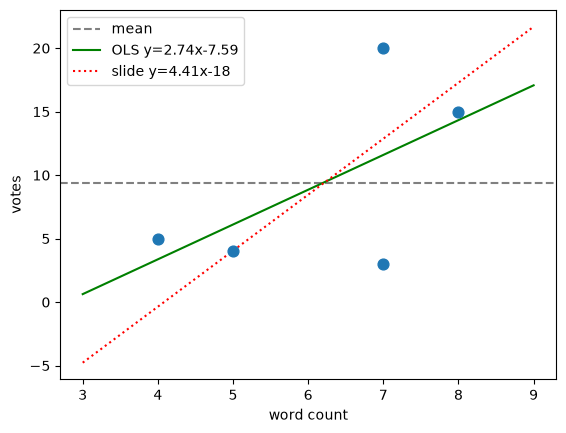

In [5]:
xs = np.linspace(3, 9, 50)
plt.scatter(X, Y, s=60, zorder=3)
plt.axhline(y_bar, ls="--", c="gray", label="mean")
plt.plot(xs, m*xs + c, c="g", label=f"OLS y={m:.2f}x{c:+.2f}")
plt.plot(xs, 4.41*xs - 18, "r:", label="slide y=4.41x-18")
plt.legend(); plt.xlabel("word count"); plt.ylabel("votes"); plt.show()

## Part B — MSE is convex in the parameters

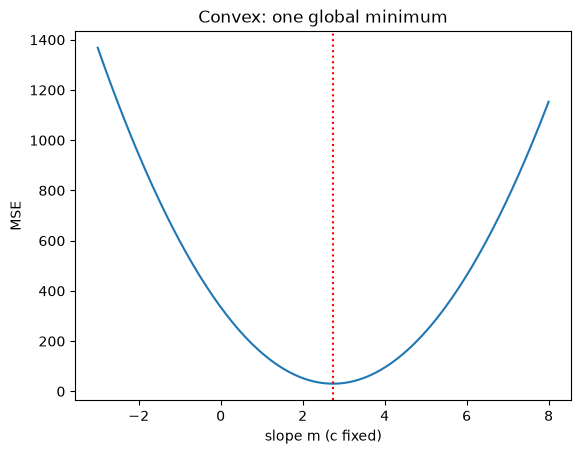

In [6]:
ms = np.linspace(-3, 8, 200)
plt.plot(ms, [mse(mm * X + c) for mm in ms])
plt.axvline(m, c="r", ls=":")
plt.xlabel("slope m (c fixed)"); plt.ylabel("MSE"); plt.title("Convex: one global minimum"); plt.show()

## Part C — Gradient descent from scratch
Cost (slide notation): $C(w_0,w_1) = \frac{1}{2M}\sum (w_0 + w_1x_i - y_i)^2$

Updates: $w_0 \leftarrow w_0 - \alpha\frac1M\sum(w_0+w_1x_i-y_i)$, $w_1 \leftarrow w_1 - \alpha\frac1M\sum(w_0+w_1x_i-y_i)x_i$

GD result: w1 (slope) = 2.7407, w0 (intercept) = -7.5926   | OLS: 2.7407, -7.5926


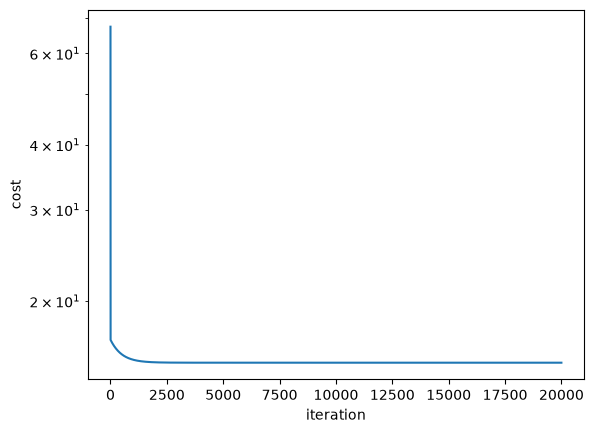

In [7]:
def gradient_descent(x, y, alpha=0.01, iters=1000, w0=0.0, w1=0.0):
    M = len(x)
    history = []
    for _ in range(iters):
        err = w0 + w1 * x - y                 # prediction − truth, for every sample
        cost = (err ** 2).sum() / (2 * M)
        history.append(cost)
        grad_w0 = err.sum() / M
        grad_w1 = (err * x).sum() / M
        w0, w1 = w0 - alpha * grad_w0, w1 - alpha * grad_w1   # simultaneous update
    return w0, w1, history

w0, w1, hist = gradient_descent(X, Y, alpha=0.02, iters=20000)
print(f"GD result: w1 (slope) = {w1:.4f}, w0 (intercept) = {w0:.4f}   | OLS: {m:.4f}, {c:.4f}")
plt.plot(hist); plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("cost"); plt.show()

In [8]:
# Why so many iterations? x is not centred (values 4..8), so the cost valley is long and narrow.
# Standardising x makes GD converge in a few dozen steps:
xs_ = (X - X.mean()) / X.std()
a0, a1, h2 = gradient_descent(xs_, Y, alpha=0.5, iters=50)
slope = a1 / X.std(); intercept = a0 - a1 * X.mean() / X.std()   # convert back to original units
print(f"standardised GD (50 iters): slope = {slope:.4f}, intercept = {intercept:.4f}")

standardised GD (50 iters): slope = 2.7407, intercept = -7.5926


## Part D — Learning rate & GD variants (synthetic data, 200 points)

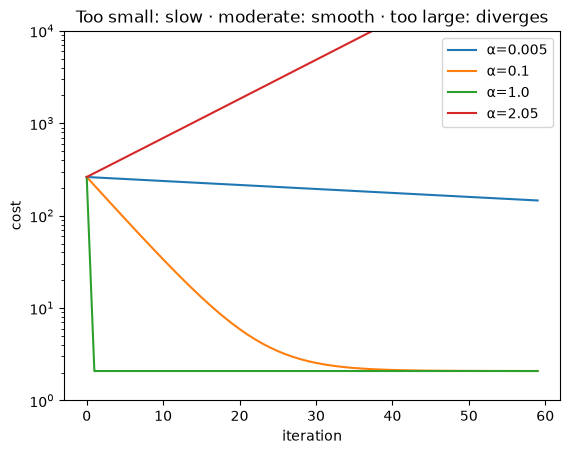

In [9]:
rng = np.random.default_rng(0)
xb = rng.uniform(0, 10, 200); yb = 3 * xb + 5 + rng.normal(0, 2, 200)   # true: slope 3, intercept 5
xb_s = (xb - xb.mean()) / xb.std()

for a in [0.005, 0.1, 1.0, 2.05]:
    _, _, h = gradient_descent(xb_s, yb, alpha=a, iters=60)
    plt.plot(h, label=f"α={a}")
plt.yscale("log"); plt.ylim(1, 1e4); plt.legend(); plt.xlabel("iteration"); plt.ylabel("cost")
plt.title("Too small: slow · moderate: smooth · too large: diverges"); plt.show()

Batch           slope=2.316 intercept=4.001  final cost=14.072
Stochastic      slope=3.141 intercept=4.213  final cost=2.262


Mini-batch(16)  slope=2.964 intercept=5.044  final cost=2.086


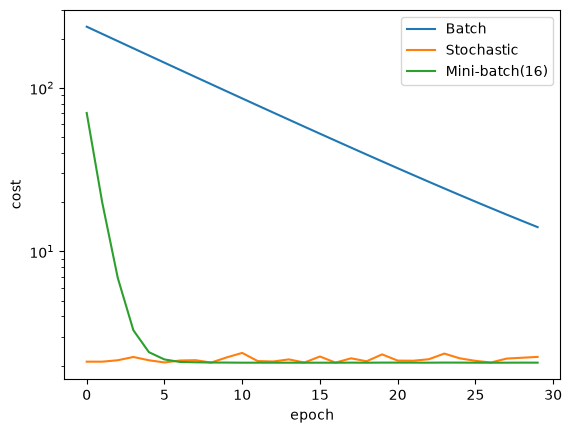

In [10]:
def minibatch_gd(x, y, batch, alpha=0.05, epochs=30, seed=1):
    r = np.random.default_rng(seed); w0 = w1 = 0.0; n = len(x); hist = []
    for _ in range(epochs):
        idx = r.permutation(n)                     # shuffle every epoch
        for s in range(0, n, batch):
            b = idx[s:s + batch]
            err = w0 + w1 * x[b] - y[b]
            w0 -= alpha * err.mean(); w1 -= alpha * (err * x[b]).mean()
        hist.append(np.mean((w0 + w1 * x - y) ** 2) / 2)    # cost on full data after each epoch
    return w0, w1, hist

for batch, name in [(200, "Batch"), (1, "Stochastic"), (16, "Mini-batch(16)")]:
    w0_, w1_, h = minibatch_gd(xb_s, yb, batch)
    # Batch makes only 1 update per epoch, so after 30 epochs it has not converged yet
    print(f"{name:15s} slope={w1_/xb.std():.3f} intercept={w0_ - w1_*xb.mean()/xb.std():.3f}  final cost={h[-1]:.3f}")
    plt.plot(h, label=name)
plt.yscale("log"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("cost"); plt.show()

## Part E — Polynomial regression & over-fitting

,train MSE,test MSE
degree,,
1,14.04,14.35
2,8.50,7.98
3,4.96,3.59
5,4.32,3.15
9,4.12,3.13
15,3.16,544.06


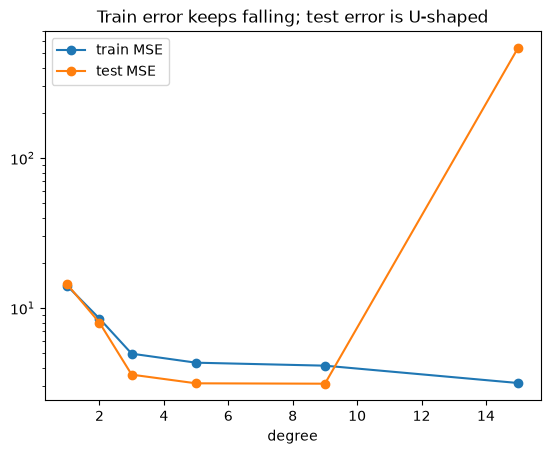

In [11]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

r = np.random.default_rng(3)
xp = r.uniform(-3, 3, 60); yp = 0.5 * xp**3 - xp**2 + 2 + r.normal(0, 2, 60)
xtr, xte, ytr, yte = train_test_split(xp.reshape(-1, 1), yp, test_size=0.3, random_state=0)

rows = []
for d in [1, 2, 3, 5, 9, 15]:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(xtr, ytr)
    rows.append((d, mean_squared_error(ytr, model.predict(xtr)), mean_squared_error(yte, model.predict(xte))))
res = pd.DataFrame(rows, columns=["degree", "train MSE", "test MSE"]).set_index("degree")
display(res.round(2))
res.plot(marker="o", logy=True, title="Train error keeps falling; test error is U-shaped"); plt.show()

## Part F — Multivariate linear regression
Salary example from the slides: experience split into teaching ($x_1$), research ($x_2$), admin ($x_3$) months. Synthetic data with known true weights so we can check every method.

In [12]:
rng = np.random.default_rng(7)
M = 100
Xm = rng.uniform(0, 120, size=(M, 3))                     # months of teaching, research, admin
true_w = np.array([20000, 300, 500, 150])                 # w0 (base), w1, w2, w3  (₹ per month of experience)
Xb = np.c_[np.ones(M), Xm]                                # add x0 = 1 column → shape (M, N+1)
y = Xb @ true_w + rng.normal(0, 3000, M)
print("X with bias column (first 3 rows):\n", Xb[:3])

X with bias column (first 3 rows):
 [[  1.      75.0115 107.6657  93.0823]
 [  1.      27.0249  36.02   104.8264]
 [  1.       0.6318  98.5474  95.6483]]


In [13]:
# 1) Vectorised gradient descent: w := w − α (1/M) Xᵀ(Xw − y)
mu, sd = Xm.mean(0), Xm.std(0)
Xs = np.c_[np.ones(M), (Xm - mu) / sd]                    # scale features (keep bias column = 1)
w = np.zeros(4)
for _ in range(2000):
    w -= 0.1 * Xs.T @ (Xs @ w - y) / M
w_orig = np.r_[w[0] - (w[1:] * mu / sd).sum(), w[1:] / sd]   # undo scaling
print("GD              :", w_orig.round(2))

# 2) Normal equation (closed form): w = (XᵀX)⁻¹ Xᵀ y   (use solve/lstsq, never invert explicitly)
w_ne = np.linalg.lstsq(Xb, y, rcond=None)[0]
print("Normal equation :", w_ne.round(2))

# 3) scikit-learn
sk = LinearRegression().fit(Xm, y)
print("sklearn         :", np.r_[sk.intercept_, sk.coef_].round(2))
print("true weights    :", true_w)

GD              : [19668.63   300.26   505.82   148.37]
Normal equation : [19668.63   300.26   505.82   148.37]
sklearn         : [19668.63   300.26   505.82   148.37]
true weights    : [20000   300   500   150]


## Part G — Case study: house-price prediction (California Housing)

In [14]:
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, r2_score
try:
    data = fetch_california_housing(as_frame=True)       # downloads ~400 KB the first time
    target_desc = "median house value (×$100,000)"
except Exception as e:                                    # offline fallback
    print("Could not download California housing, using diabetes dataset instead:", e)
    data = load_diabetes(as_frame=True); target_desc = "disease progression"
df = data.frame
print(df.shape, "| target:", target_desc)
df.head()

(20640, 9) | target: median house value (×$100,000)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
Xh, yh = data.data.values, data.target.values
Xtr, Xte, ytr, yte = train_test_split(Xh, yh, test_size=0.2, random_state=42)

def report(name, model):
    p = model.predict(Xte)
    print(f"{name:28s} MSE={mean_squared_error(yte, p):.3f}  RMSE={np.sqrt(mean_squared_error(yte, p)):.3f}  "
          f"MAE={mean_absolute_error(yte, p):.3f}  R²={r2_score(yte, p):.3f}")

class MeanModel:
    def predict(self, X): return np.full(len(X), ytr.mean())
report("Baseline: predict the mean", MeanModel())
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr); report("LinearRegression (OLS)", ols)
sgd = make_pipeline(StandardScaler(), SGDRegressor(max_iter=1000, random_state=42)).fit(Xtr, ytr); report("SGDRegressor (gradient descent)", sgd)
coef = pd.Series(ols[-1].coef_, index=data.feature_names).sort_values(key=abs, ascending=False)
print("\nStandardised coefficients (bigger |value| = more influence):\n", coef.round(3))

Baseline: predict the mean   MSE=1.311  RMSE=1.145  MAE=0.906  R²=-0.000
LinearRegression (OLS)       MSE=0.556  RMSE=0.746  MAE=0.533  R²=0.576
SGDRegressor (gradient descent) MSE=0.551  RMSE=0.742  MAE=0.530  R²=0.580

Standardised coefficients (bigger |value| = more influence):
 Latitude     -0.897
Longitude    -0.870
MedInc        0.854
AveBedrms     0.339
AveRooms     -0.294
HouseAge      0.123
AveOccup     -0.041
Population   -0.002
dtype: float64


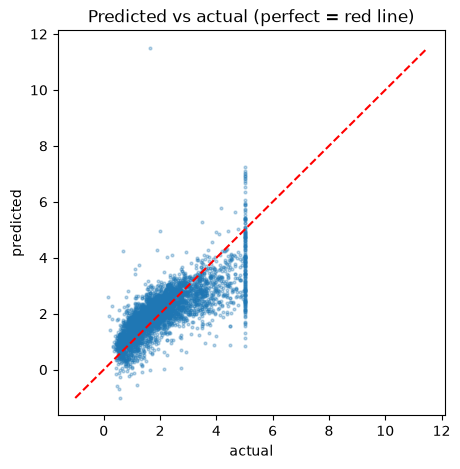

In [16]:
p = ols.predict(Xte)
plt.figure(figsize=(5, 5)); plt.scatter(yte, p, s=4, alpha=0.3)
lim = [min(yte.min(), p.min()), max(yte.max(), p.max())]; plt.plot(lim, lim, "r--")
plt.xlabel("actual"); plt.ylabel("predicted"); plt.title("Predicted vs actual (perfect = red line)"); plt.show()